<a href="https://colab.research.google.com/github/amanbhatia-analyst/image-processing-data-modelling/blob/main/Data_Modeling_image_processing_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scope

The purpose of this assignment is to implement and compare two different deep learning models,
a Recurrent Neural Network (RNN) and a Convolutional Neural Network (CNN), for the task of
image classification using the MNIST dataset.

The MNIST dataset contains grayscale images of handwritten digits (0–9), each with a size of
28x28 pixels. The models will be trained and evaluated on this dataset, and their performances
will be compared in terms of accuracy and suitability for the problem.

This experiment is meant to highlight the differences between RNNs, which are sequential models,
and CNNs, which are specialized for image processing.


## Load the dataset using tensorflow (tf)...

The MNIST dataset is loaded using TensorFlow here.
- The pixel values of the images are normalized to the range [0, 1] to make training easier.  
- For the CNN model, the images are kept in their original 2D grid format (28x28).  
- For the RNN model, the images are kept in the [28,28] grid also.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

# Load MNIST dataset from TensorFlow tf...
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to 0 and 1, [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape for RNN: Keeping dimensions as [28,28] grid.
x_train_rnn = x_train.reshape(-1, 28,28)
x_test_rnn = x_test.reshape(-1, 28, 28)

# Reshaping for CNN: Add channel dimension (28, 28, 1)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding using keras tensorflow...
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training data shape (RNN):", x_train_rnn.shape)
print("Training data shape (CNN):", x_train_cnn.shape)
print("Training labels shape:", y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape (RNN): (60000, 28, 28)
Training data shape (CNN): (60000, 28, 28, 1)
Training labels shape: (60000, 10)


## Implement the two models.

- 1. RNN Model...

In [ ]:
from tensorflow.keras import layers, models

def create_simple_rnn(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.SimpleRNN(128, input_shape=input_shape, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# Defining the input shape for RNN model
input_shape_rnn = (28, 28)
rnn_model = create_simple_rnn(input_shape_rnn, num_classes=10)

# Compile the RNN model
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the RNN model summary
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,002 (113.29 KB)

 Trainable params: 29,002 (113.29 KB)

 Non-trainable params: 0 (0.00 B)

## Implement the two models.

- 2. CNN Model...

In [ ]:
def create_simple_cnn(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# Defining the input shape for CNN
input_shape_cnn = (28, 28, 1)
cnn_model = create_simple_cnn(input_shape_cnn, num_classes=10)

# Compile the CNN model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the CNN model summary
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training and Evaluation

In [ ]:
# Train the RNN model
rnn_history = rnn_model.fit(x_train_rnn, y_train, epochs=10, batch_size=128,
                           validation_data=(x_test_rnn, y_test))

# Train the CNN model
cnn_history = cnn_model.fit(x_train_cnn, y_train, epochs=10, batch_size=128,
                           validation_data=(x_test_cnn, y_test))

# Evaluate the two models
rnn_loss, rnn_accuracy = rnn_model.evaluate(x_test_rnn, y_test)
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test_cnn, y_test)

print(f"RNN Test Accuracy: {rnn_accuracy:.4f}")
print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6971 - loss: 0.9077 - val_accuracy: 0.9315 - val_loss: 0.2347
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9369 - loss: 0.2092 - val_accuracy: 0.9521 - val_loss: 0.1557
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9540 - loss: 0.1530 - val_accuracy: 0.9531 - val_loss: 0.1525
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9606 - loss: 0.1324 - val_accuracy: 0.9635 - val_loss: 0.1139
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9671 - loss: 0.1118 - val_accuracy: 0.9719 - val_loss: 0.0905
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9682 - loss: 0.1054 - val_accuracy: 0.9678 - val_loss: 0.1036
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9724 - loss: 0.0905 - val_accuracy: 0.9735 - val_loss: 0.0843
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9733 - loss: 0.0899 - val_accuracy: 0

## Comparison and Analysis of the two models

### Visualizations

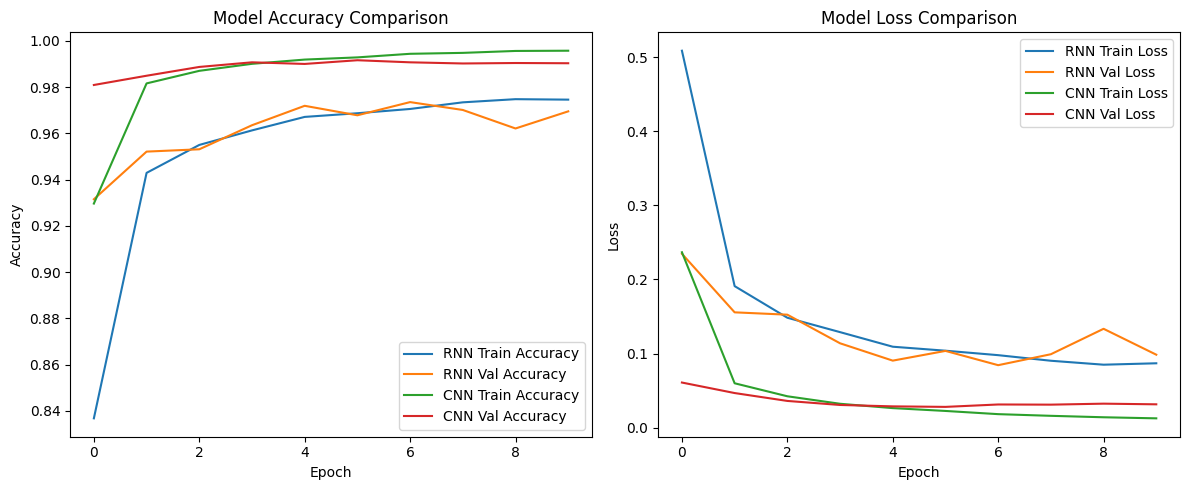

In [ ]:
import matplotlib.pyplot as plt

# Plot the training and validation accuracy
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['accuracy'], label='RNN Train Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='RNN Val Accuracy')
plt.plot(cnn_history.history['accuracy'], label='CNN Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN Val Loss')
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Using Pytorch
- Load the data using pytorch

In [ ]:
import kagglehub, shutil, os

# Download with kagglehub
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

custom_dir = "/content/my_datasets/mnist"

os.makedirs(custom_dir, exist_ok=True)

shutil.copytree(path, custom_dir, dirs_exist_ok=True)

print("Moved dataset to:", custom_dir)


Moved dataset to: /content/my_datasets/mnist


In [ ]:
import numpy as np
import torch
from torch.utils.data import TensorDataset
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def read_idx(filename):
    with open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8)
    if "images" in filename:
        return data[16:].reshape(-1, 28, 28)
    else:
        return data[8:]

path = "/content/my_datasets/mnist"

x_train = read_idx(os.path.join(path, "train-images.idx3-ubyte"))
y_train = read_idx(os.path.join(path, "train-labels.idx1-ubyte"))
x_test  = read_idx(os.path.join(path, "t10k-images.idx3-ubyte"))
y_test  = read_idx(os.path.join(path, "t10k-labels.idx1-ubyte"))

# normalize and convert to tensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

x_train = torch.stack([transform(img) for img in x_train])
x_test  = torch.stack([transform(img) for img in x_test])
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(x_train, y_train)
test_dataset  = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


Train shape: torch.Size([60000, 1, 28, 28])
Test shape: torch.Size([10000, 1, 28, 28])


## Implement the two models
- The RNN Model

In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

# Initialize the RNN model
rnn_model = SimpleRNN(input_size=28, hidden_size=128, num_classes=10)

## Implement the two models...
- The CNN Model

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.relu(self.conv3(x))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the CNN model
cnn_model = SimpleCNN(num_classes=10)

## Training the two models, and Evaluation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
rnn_model.to(device)
cnn_model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Training function
def train_model(model, train_loader, criterion, optimizer, num_epochs, is_rnn=False):
    model.train()
    history = {'train_loss': [], 'train_acc': []}

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            if is_rnn:
                # RNN expects shape [batch, seq_len, features] = [batch, 28, 28]
                images = images.view(-1, 28, 28)
            else:
                # CNN expects [batch, 1, 28, 28]
                images = images.view(-1, 1, 28, 28)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

    return history

# Evaluation function
def evaluate_model(model, test_loader, is_rnn=False):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            if is_rnn:
                images = images.view(-1, 28, 28)
            else:
                images = images.view(-1, 1, 28, 28)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy

# Train the models
num_epochs = 10
rnn_history = train_model(rnn_model, train_loader, criterion, rnn_optimizer, num_epochs, is_rnn=True)
cnn_history = train_model(cnn_model, train_loader, criterion, cnn_optimizer, num_epochs, is_rnn=False)

# Evaluate the models
rnn_accuracy = evaluate_model(rnn_model, test_loader, is_rnn=True)
cnn_accuracy = evaluate_model(cnn_model, test_loader, is_rnn=False)

print(f"RNN Test Accuracy: {rnn_accuracy:.4f}")
print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")


Epoch 1/10, Loss: 0.9127, Acc: 0.6850
Epoch 2/10, Loss: 0.4169, Acc: 0.8763
Epoch 3/10, Loss: 0.3286, Acc: 0.9052
Epoch 4/10, Loss: 0.2622, Acc: 0.9249
Epoch 5/10, Loss: 0.2376, Acc: 0.9319
Epoch 6/10, Loss: 0.2155, Acc: 0.9383
Epoch 7/10, Loss: 0.1918, Acc: 0.9448
Epoch 8/10, Loss: 0.1749, Acc: 0.9497
Epoch 9/10, Loss: 0.1699, Acc: 0.9510
Epoch 10/10, Loss: 0.1512, Acc: 0.9557
Epoch 1/10, Loss: 0.2215, Acc: 0.9295
Epoch 2/10, Loss: 0.0512, Acc: 0.9846
Epoch 3/10, Loss: 0.0343, Acc: 0.9893
Epoch 4/10, Loss: 0.0284, Acc: 0.9911
Epoch 5/10, Loss: 0.0211, Acc: 0.9933
Epoch 6/10, Loss: 0.0183, Acc: 0.9939
Epoch 7/10, Loss: 0.0135, Acc: 0.9955
Epoch 8/10, Loss: 0.0135, Acc: 0.9953
Epoch 9/10, Loss: 0.0104, Acc: 0.9965
Epoch 10/10, Loss: 0.0104, Acc: 0.9964
RNN Test Accuracy: 0.9494
CNN Test Accuracy: 0.9909


## Comparison (Using Visualizations) and Analysis

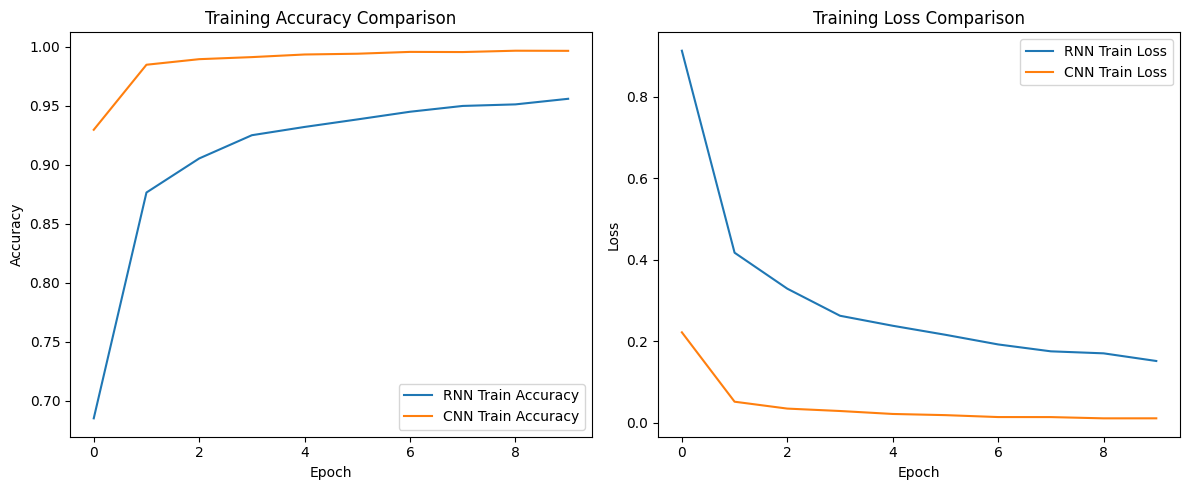

In [ ]:
import matplotlib.pyplot as plt

# Plot training accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rnn_history['train_acc'], label='RNN Train Accuracy')
plt.plot(cnn_history['train_acc'], label='CNN Train Accuracy')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training loss
plt.subplot(1, 2, 2)
plt.plot(rnn_history['train_loss'], label='RNN Train Loss')
plt.plot(cnn_history['train_loss'], label='CNN Train Loss')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Confusion Matrix

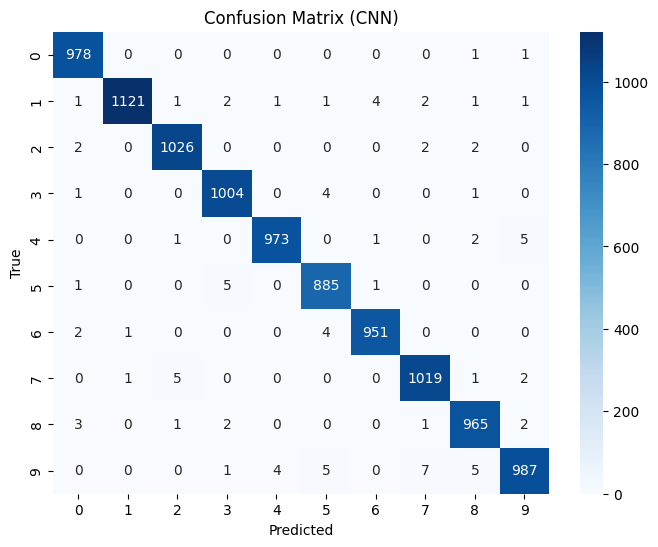

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


all_preds, all_labels = [], []
cnn_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (CNN)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


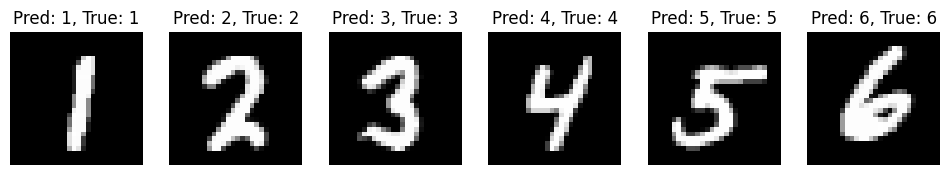

In [ ]:
# Show some predictions
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i].cpu().squeeze(), cmap="gray")
    ax.set_title(f"Pred: {preds[i].item()}, True: {labels[i].item()}")
    ax.axis("off")
plt.show()

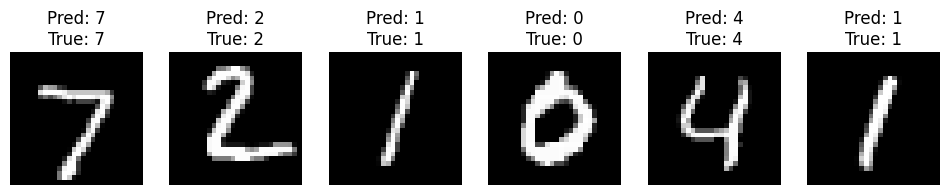

In [ ]:
# Sample predictions from the CNN model.
cnn_model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    outputs = cnn_model(images)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i].cpu().squeeze(), cmap="gray")
    ax.set_title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    ax.axis("off")
plt.show()